# KCell Enclosure

`KCellEnclosure` is the cell-level counterpart to `LayerEnclosure`.  Where
`LayerEnclosure` processes the geometry of a *single component*, `KCellEnclosure`:

1. **Recurses into all sub-cells** (`begin_shapes_rec`) to collect geometry.
2. **Merges** the collected geometry into one `Region` before computing the expansion.
3. Applies one or more `LayerEnclosure` rules in a single pass.

This guarantees a continuous cladding across component joints — no gaps at the
seams between adjacent waveguides or bends.

| Class | Scope | Gap-free joins |
|---|---|---|
| `LayerEnclosure` | one component at a time | no — each component enclosed separately |
| `KCellEnclosure` | entire assembled cell | yes — geometry merged first |

The [Layer Enclosure](layer_enclosure.md) page introduces `LayerEnclosure` and shows a
basic `KCellEnclosure` example.  This page covers advanced usage: multiple enclosures,
tiling parameters, and the directional Minkowski methods.

## Setup

In [1]:
import kfactory as kf


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGCLAD: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)
    SLAB: kf.kdb.LayerInfo = kf.kdb.LayerInfo(3, 0)
    NPP: kf.kdb.LayerInfo = kf.kdb.LayerInfo(4, 0)
    DEEPOX: kf.kdb.LayerInfo = kf.kdb.LayerInfo(5, 0)


L = LAYER()
kf.kcl.infos = L

## 1 · Single enclosure

The minimal usage: wrap one `LayerEnclosure` in a `KCellEnclosure` and call
`apply_minkowski_tiled` on the finished cell.

The key rules are:
- Call `apply_minkowski_tiled` **inside** the `@kf.cell` function, before `return c`.
- The `LayerEnclosure` must have `main_layer` set so the processor knows which layer
  to expand.

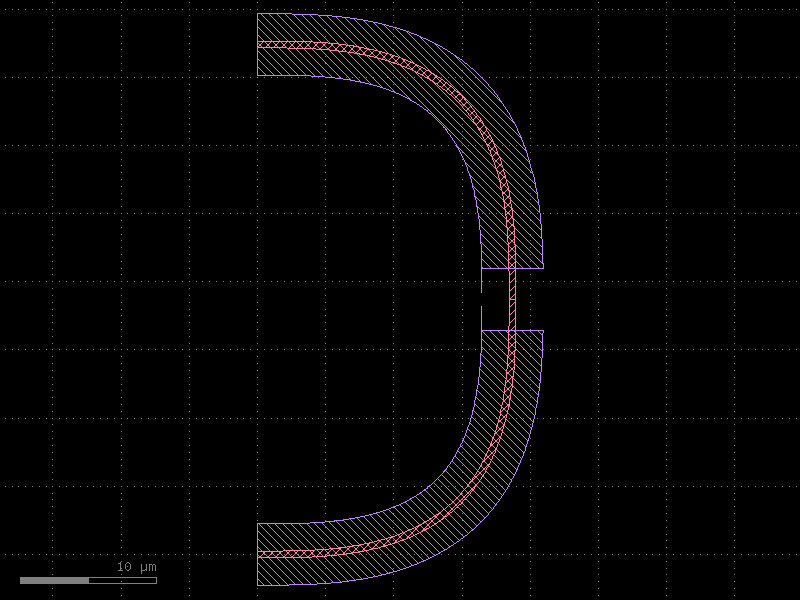

In [2]:
clad_enc = kf.LayerEnclosure(
    dsections=[(L.WGCLAD, 2.0)],
    name="WG_CLAD",
    main_layer=L.WG,
    kcl=kf.kcl,
)

kcell_enc = kf.KCellEnclosure([clad_enc])


@kf.cell
def bend_pair_clad(radius: float, width: float) -> kf.KCell:
    """Two euler bends with unified cell-level cladding."""
    c = kf.KCell()
    bend_fn = kf.factories.euler.bend_euler_factory(kcl=kf.kcl)

    b1 = c << bend_fn(width=width, radius=radius, layer=L.WG, angle=90)
    b2 = c << bend_fn(width=width, radius=radius, layer=L.WG, angle=90)

    # Join b2 to b1 so the waveguides share a port
    b2.connect("o1", b1.ports["o2"])

    c.add_ports(b1.ports.filter(port_type="optical"))
    c.add_ports(b2.ports.filter(port_type="optical"))
    c.auto_rename_ports()

    # Apply unified cladding to the finished assembly
    kcell_enc.apply_minkowski_tiled(c)
    return c


bend_pair_clad(radius=10, width=0.5).plot()

The WGCLAD forms a single, continuous band around both bends — there is no gap at the
port where they connect.

## 2 · Multiple enclosures in one `KCellEnclosure`

Pass a list of `LayerEnclosure` objects to cover several output layers in a single
`apply_minkowski_tiled` call.  The processor iterates over them in order.

2026-05-12 10:04:22.475 | ERROR    | kfactory.kcell:name:698 - Name conflict in kfactory.kcell::name at line 698
Renaming Unnamed_4 (cell_index=4) to bend_euler_W0p5_R10_LWG_ENone_A90_R150 would cause it to be named the same as:
 - bend_euler_W0p5_R10_LWG_ENone_A90_R150 (cell_index=1), function_name=bend_euler, basename=None


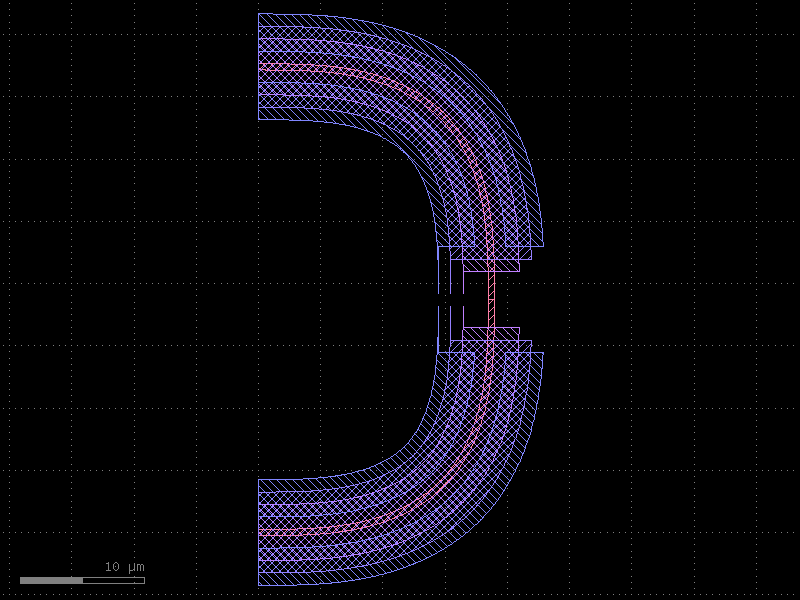

In [3]:
slab_enc = kf.LayerEnclosure(
    dsections=[(L.SLAB, 3.0)],
    name="WG_SLAB",
    main_layer=L.WG,
    kcl=kf.kcl,
)

npp_enc = kf.LayerEnclosure(
    dsections=[(L.NPP, 1.0, 4.0)],  # annular: 1 µm to 4 µm from WG edge
    name="WG_NPP",
    main_layer=L.WG,
    kcl=kf.kcl,
)

# Combine three enclosures: cladding + slab + implant
multi_enc = kf.KCellEnclosure([clad_enc, slab_enc, npp_enc])


@kf.cell
def bend_pair_multi(radius: float, width: float) -> kf.KCell:
    """Two euler bends with multi-layer cell-level enclosure."""
    c = kf.KCell()
    bend_fn = kf.factories.euler.bend_euler_factory(kcl=kf.kcl)

    b1 = c << bend_fn(width=width, radius=radius, layer=L.WG, angle=90)
    b2 = c << bend_fn(width=width, radius=radius, layer=L.WG, angle=90)
    b2.connect("o1", b1.ports["o2"])

    c.add_ports(b1.ports.filter(port_type="optical"))
    c.add_ports(b2.ports.filter(port_type="optical"))
    c.auto_rename_ports()

    multi_enc.apply_minkowski_tiled(c)
    return c


bend_pair_multi(radius=10, width=0.5).plot()

Three generated layers are visible:
- **WGCLAD** — 2 µm uniform cladding
- **SLAB** — 3 µm uniform slab
- **NPP** — annular implant from 1 µm to 4 µm outside the WG edge

## 3 · Tiling parameters

`apply_minkowski_tiled` uses KLayout's `TilingProcessor` for parallel computation.
The key parameters are:

| Parameter | Default | Effect |
|---|---|---|
| `tile_size` | `None` (auto) | Tile edge length in µm. Auto = max(10×max_d, 200 µm). |
| `n_pts` | 64 | Points in the circular kernel. Fewer = faster but more angular corners. |
| `n_threads` | `None` (all CPUs) | Override thread count (useful in CI). |
| `carve_out_ports` | `True` | Remove cladding from port openings so waveguides remain accessible. |

### Effect of `n_pts` on corner shape

2026-05-12 10:04:22.630 | ERROR    | kfactory.kcell:name:698 - Name conflict in kfactory.kcell::name at line 698
Renaming Unnamed_7 (cell_index=7) to bend_euler_W0p5_R10_LWG_ENone_A90_R150 would cause it to be named the same as:
 - bend_euler_W0p5_R10_LWG_ENone_A90_R150 (cell_index=1), function_name=bend_euler, basename=None
 - bend_euler_W0p5_R10_LWG_ENone_A90_R150 (cell_index=4), function_name=bend_euler, basename=None


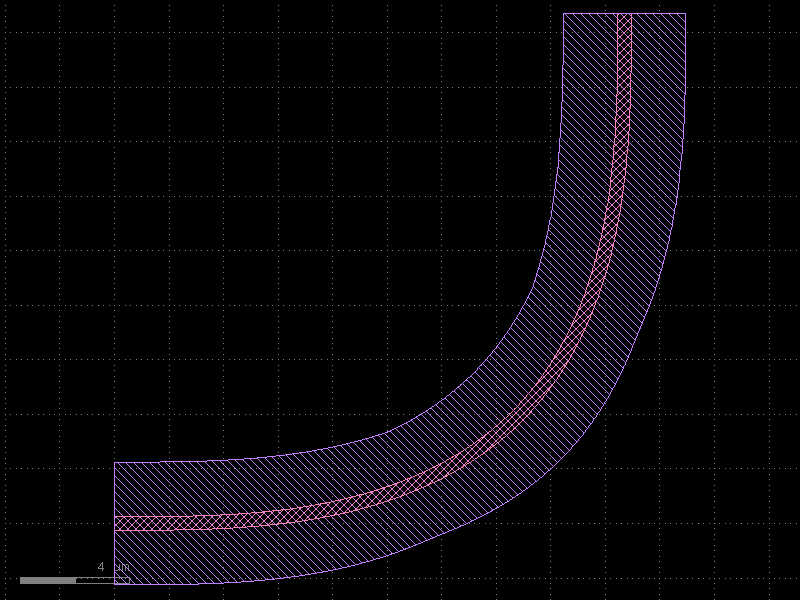

In [4]:
enc_coarse = kf.KCellEnclosure([clad_enc])
enc_fine = kf.KCellEnclosure([clad_enc])


@kf.cell
def single_bend_npts(radius: float, width: float, n_pts: int) -> kf.KCell:
    """Euler bend with variable n_pts for corner resolution."""
    c = kf.KCell()
    b = c << kf.factories.euler.bend_euler_factory(kcl=kf.kcl)(
        width=width, radius=radius, layer=L.WG, angle=90
    )
    c.add_ports(b.ports)
    c.auto_rename_ports()
    kf.KCellEnclosure([clad_enc]).apply_minkowski_tiled(c, n_pts=n_pts)
    return c


# n_pts=8 → octagonal corners
single_bend_npts(radius=10, width=0.5, n_pts=8).plot()

With `n_pts=8` the corners of the WGCLAD are octagonal.  The default `n_pts=64`
produces near-circular corners.

2026-05-12 10:04:22.654 | ERROR    | kfactory.kcell:name:698 - Name conflict in kfactory.kcell::name at line 698
Renaming Unnamed_10 (cell_index=10) to bend_euler_W0p5_R10_LWG_ENone_A90_R150 would cause it to be named the same as:
 - bend_euler_W0p5_R10_LWG_ENone_A90_R150 (cell_index=1), function_name=bend_euler, basename=None
 - bend_euler_W0p5_R10_LWG_ENone_A90_R150 (cell_index=4), function_name=bend_euler, basename=None
 - bend_euler_W0p5_R10_LWG_ENone_A90_R150 (cell_index=7), function_name=bend_euler, basename=None


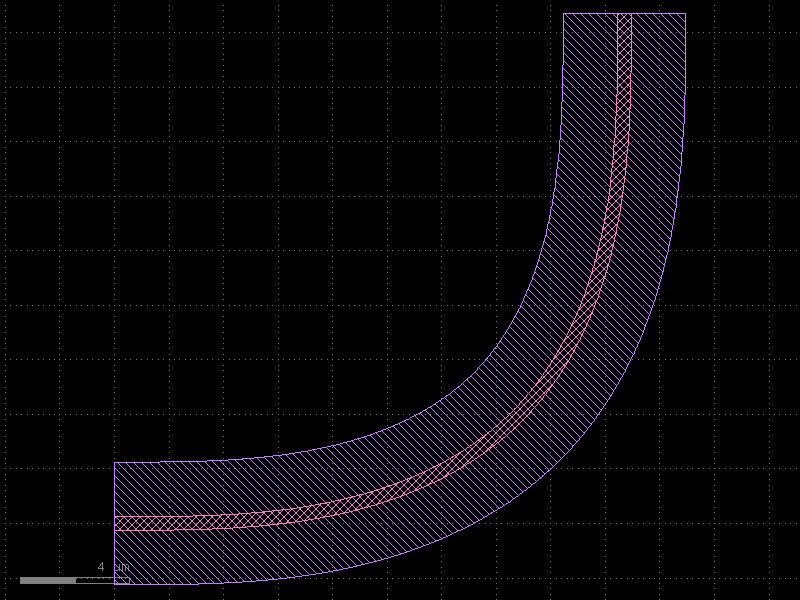

In [5]:
# n_pts=64 → smooth circular corners (default)
single_bend_npts(radius=10, width=0.5, n_pts=64).plot()

### Controlling threads for CI environments

```python
# Use a fixed thread count for reproducible timing in CI
kcell_enc.apply_minkowski_tiled(c, n_threads=1)
```

## 4 · `apply_minkowski_y` — directional enclosure for horizontal waveguides

`apply_minkowski_tiled` uses a circle as the Minkowski kernel, producing rounded
corners on all sides.  For **horizontal straight waveguides** this is often
undesirable — you want the cladding to extend only *above and below* the waveguide
(Y direction) without rounding the ends.

`apply_minkowski_y` uses a vertical edge `(0, −d) → (0, d)` as the kernel:
- Expands in the **Y direction** by `d`.
- No expansion in the X direction — cladding ends flush with the waveguide ends.

This is useful when the port openings must remain clear, or when the cladding
rectangle must match the exact waveguide length.

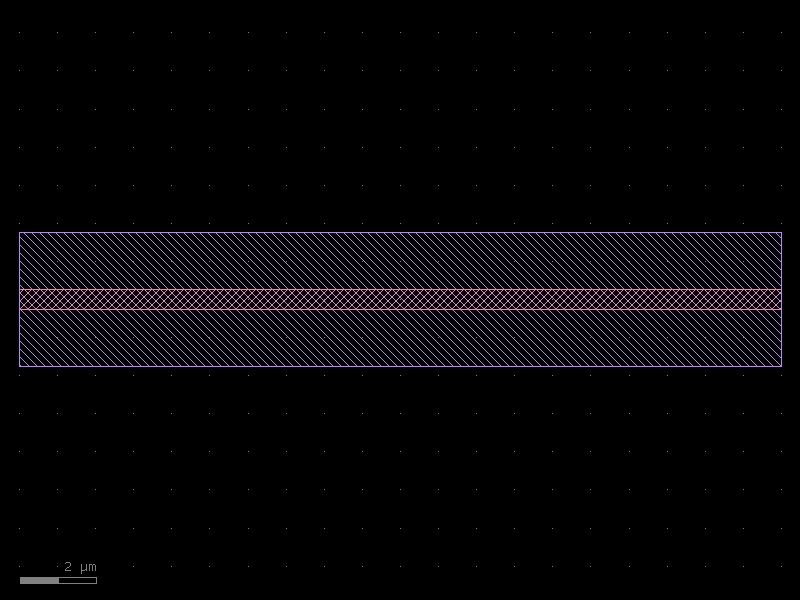

In [6]:
clad_enc_y = kf.LayerEnclosure(
    dsections=[(L.WGCLAD, 1.5)],
    name="CLAD_Y",
    main_layer=L.WG,
    kcl=kf.kcl,
)
kcell_enc_y = kf.KCellEnclosure([clad_enc_y])


@kf.cell
def straight_clad_y(length: float, width: float) -> kf.KCell:
    """Horizontal straight waveguide with Y-only cladding."""
    c = kf.KCell()
    s = c << kf.factories.straight.straight_dbu_factory(kcl=kf.kcl)(
        length=kf.kcl.to_dbu(length),
        width=kf.kcl.to_dbu(width),
        layer=L.WG,
    )
    c.add_ports(s.ports)
    c.auto_rename_ports()
    # Expand cladding in Y only — no rounding at port ends
    kcell_enc_y.apply_minkowski_y(c)
    return c


straight_clad_y(length=20.0, width=0.5).plot()

The WGCLAD (layer 2/0) extends 1.5 µm above and below the waveguide but ends
exactly at the port faces — no overextension at the ends.

## 5 · `apply_minkowski_x` — directional enclosure for vertical waveguides

`apply_minkowski_x` is the X-direction counterpart.  It uses a horizontal edge
`(−d, 0) → (d, 0)` as the kernel, expanding only left and right.  This is the
correct choice for waveguides oriented vertically (angle 90° / 270°).

2026-05-12 10:04:22.725 | ERROR    | kfactory.kcell:name:698 - Name conflict in kfactory.kcell::name at line 698
Renaming Unnamed_16 (cell_index=16) to straight_W500_L20000_LWG_ENone would cause it to be named the same as:
 - straight_W500_L20000_LWG_ENone (cell_index=13), function_name=straight, basename=None


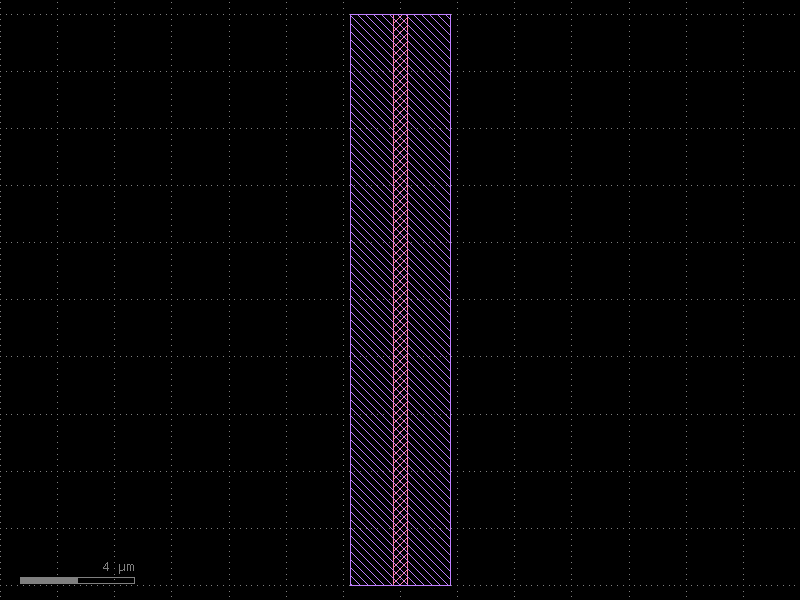

In [7]:
kcell_enc_x = kf.KCellEnclosure([clad_enc_y])


@kf.cell
def vertical_straight_clad_x(length: float, width: float) -> kf.KCell:
    """Vertical straight waveguide with X-only cladding."""
    c = kf.KCell()
    s = c << kf.factories.straight.straight_dbu_factory(kcl=kf.kcl)(
        length=kf.kcl.to_dbu(length),
        width=kf.kcl.to_dbu(width),
        layer=L.WG,
    )
    # Rotate 90° so the waveguide runs vertically
    s.drotate(90)
    c.add_ports(s.ports)
    c.auto_rename_ports()
    kcell_enc_x.apply_minkowski_x(c)
    return c


vertical_straight_clad_x(length=20.0, width=0.5).plot()

## 6 · `apply_minkowski_custom` — custom kernel shape

For full control over the expansion shape pass a callable to
`apply_minkowski_custom`.  The callable receives the expansion distance `d` (in DBU)
and must return a `kdb.Edge`, `kdb.Polygon`, or `kdb.Box`.

### Diamond kernel

A diamond (rotated square) rounds corners at 45° — a good compromise between a box
(very angular) and a circle (many points, slower).

2026-05-12 10:04:22.747 | ERROR    | kfactory.kcell:name:698 - Name conflict in kfactory.kcell::name at line 698
Renaming Unnamed_19 (cell_index=19) to bend_euler_W0p5_R10_LWG_ENone_A90_R150 would cause it to be named the same as:
 - bend_euler_W0p5_R10_LWG_ENone_A90_R150 (cell_index=1), function_name=bend_euler, basename=None
 - bend_euler_W0p5_R10_LWG_ENone_A90_R150 (cell_index=4), function_name=bend_euler, basename=None
 - bend_euler_W0p5_R10_LWG_ENone_A90_R150 (cell_index=7), function_name=bend_euler, basename=None
 - bend_euler_W0p5_R10_LWG_ENone_A90_R150 (cell_index=10), function_name=bend_euler, basename=None


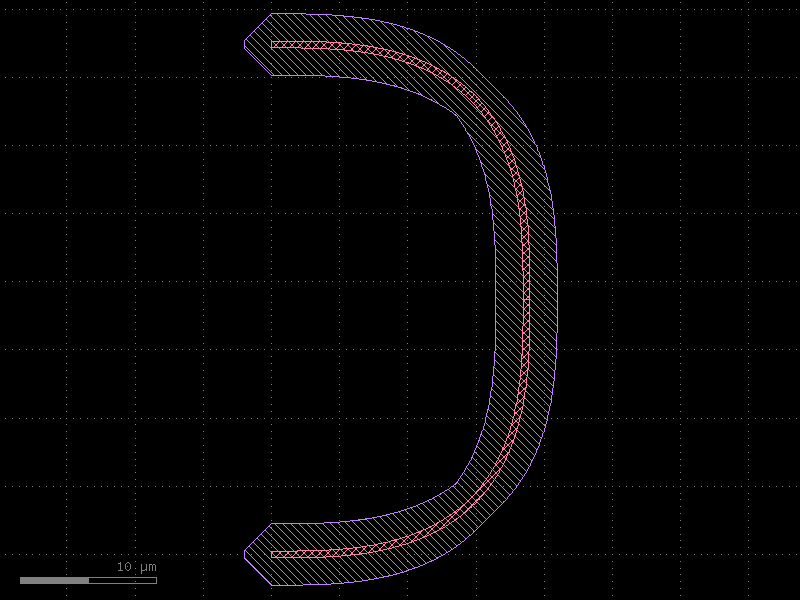

In [8]:
def diamond(d: int) -> kf.kdb.Polygon:
    """Return a diamond-shaped polygon with half-diagonal d."""
    return kf.kdb.Polygon(
        [
            kf.kdb.Point(0, d),
            kf.kdb.Point(d, 0),
            kf.kdb.Point(0, -d),
            kf.kdb.Point(-d, 0),
        ]
    )


kcell_enc_diamond = kf.KCellEnclosure([clad_enc])


@kf.cell
def bend_pair_diamond(radius: float, width: float) -> kf.KCell:
    """Two euler bends with diamond-kernel cell-level cladding."""
    c = kf.KCell()
    bend_fn = kf.factories.euler.bend_euler_factory(kcl=kf.kcl)

    b1 = c << bend_fn(width=width, radius=radius, layer=L.WG, angle=90)
    b2 = c << bend_fn(width=width, radius=radius, layer=L.WG, angle=90)
    b2.connect("o1", b1.ports["o2"])

    c.add_ports(b1.ports.filter(port_type="optical"))
    c.add_ports(b2.ports.filter(port_type="optical"))
    c.auto_rename_ports()

    kcell_enc_diamond.apply_minkowski_custom(c, shape=diamond)
    return c


bend_pair_diamond(radius=10, width=0.5).plot()

The WGCLAD corners are diamond-shaped (45° chamfers).

## 7 · Method reference

| Method | Kernel | Expands | Best for |
|---|---|---|---|
| `apply_minkowski_tiled` | circle (`n_pts` points) | all directions | complex / curved cells |
| `apply_minkowski_y` | vertical edge | Y only | horizontal straight waveguides |
| `apply_minkowski_x` | horizontal edge | X only | vertical straight waveguides |
| `apply_minkowski_custom(c, shape)` | user-supplied | custom | custom corner shapes |

### Directional method comparison

| Method | Corners | Port openings | Computation |
|---|---|---|---|
| `apply_minkowski_tiled` | rounded | carved out (`carve_out_ports=True`) | tiled, parallel |
| `apply_minkowski_y` | square (no rounding) | flush at port ends | single-pass |
| `apply_minkowski_x` | square (no rounding) | flush at port ends | single-pass |
| `apply_minkowski_custom` | matches kernel | depends on kernel | single-pass |

### Quick-start checklist

1. Always set `main_layer=` on every `LayerEnclosure` used inside `KCellEnclosure`.
2. Call the apply method **inside** the `@kf.cell` function, before `return c`.
3. For large or curved cells use `apply_minkowski_tiled` (parallel, circle kernel).
4. For straight waveguides use `apply_minkowski_y` / `apply_minkowski_x` to keep
   cladding flush with port faces.
5. Adjust `n_pts` in `apply_minkowski_tiled` to trade corner resolution for speed.

## See Also

| Topic | Where |
|-------|-------|
| Layer enclosures (single-layer) | [Enclosures: Layer Enclosure](layer_enclosure.py) |
| Cross-sections (port geometry) | [Cross-Sections](../components/cross_sections.py) |
| Boolean / region operations | [Core Concepts: Geometry](../concepts/geometry.py) |
| Tile-based fill | [Utilities: Fill](../utilities/fill.py) |